In [605]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import shutil

Changes:
- Increase dropout 0.3
- Change bin and max freq

1. SETTING UP ENVIRONMENT

In [606]:
# Define directory for saving results

filepath = 'Tests/Fourier/38'
script_dir = os.path.dirname('mlp fourier.ipynb')
results_dir = os.path.join(script_dir, filepath + '/')

if not os.path.isdir(results_dir):
    os.makedirs(results_dir)

In [607]:
# Set random seed for reproducibility

torch.manual_seed(7)  # PyTorch seed
np.random.seed(7)     # NumPy seed

In [608]:
# Select computation device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


2. HYPERPARAMETER CONFIGURATION

In [609]:
num_classes = 7       # Number of classes (coins)
epochs = 500          # Number of training epochs
batch_size = 8       # Mini-batch size
learning_rate = 0.0001 # Initial learning 
dropout = 0.3

take_max=True
freq_number = 10      # Number of frequency features selected
bin_size = 1500
norm = "individual"

3. LOAD AND PROCESS DATA

In [610]:
# Load dataset from file
data = np.load('./coin_data.npy')

In [611]:
mapping = {
       0:"1 Cent",
       1:"2 Cent",
       2:"5 Cent",
       3:"20 Cent",
       4:"50 Cent",
       5:"1 Euro",
       6:"2 Euro"
}

In [612]:
def compute_fft_features(data, sample_rate=204000):
    
    """
    Computes FFT features from time-series data.
    
    Parameters:
        data (numpy array): Input dataset where first column is the label.
        sample_rate (int): Sampling rate of the audio.
    Returns:
        labels (numpy array): Extracted labels.
        fft_magnitudes (numpy array): FFT magnitude values.
        freqs (numpy array): Corresponding frequency values.
    """

    labels = data[:, 0]  # Extract labels
    signals = data[:, 1:]  # Extract time-series signals
    N = signals.shape[1]  # Number of time points00

    try:
        fft_magnitudes = np.load('./fft_magnitudes.npy')
    except:
        fft_features = np.fft.rfft(signals, axis=1) # Compute FFT
        fft_magnitudes = np.abs(fft_features)  # Compute magnitude
        np.save('fft_magnitudes', fft_magnitudes)


    freqs = np.fft.rfftfreq(N, d=1/sample_rate) # Compute actual freq. val.

    return labels, fft_magnitudes, freqs

In [613]:
def bin_fft_frequencies(fft_magnitudes, freqs, bin_size, take_max):
    """
    Bins the FFT magnitudes by either averaging or taking the max over a range of frequency bins.
    
    Parameters:
        fft_magnitudes (numpy array): FFT magnitude values (batch_size, num_freq_bins).
        freqs (numpy array): Corresponding frequency values (num_freq_bins,).
        bin_size (int): Number of frequency bins to group.
        take_max (bool): If True, takes the maximum value in each bin, otherwise averages.
    
    Returns:
        binned_magnitudes (numpy array): Magnitudes after binning (batch_size, num_bins).
        binned_freqs (numpy array): New binned frequency values (num_bins,).
    """
    # Determine the number of bins (group frequencies into bins of bin_size)
    num_freq_bins = fft_magnitudes.shape[1]
    num_bins = num_freq_bins // bin_size

    binned_magnitudes = []
    binned_freqs = []

    for i in range(num_bins):
        start_idx = i * bin_size
        end_idx = min((i + 1) * bin_size, num_freq_bins)

        if take_max:
            # Get the max amplitude across all samples for the current frequency bin
            bin_magnitude = np.max(fft_magnitudes[:, start_idx:end_idx], axis=1)
            
            # Find the frequency with the max amplitude (max across samples in that range)
            max_idx = np.argmax(np.max(fft_magnitudes[:, start_idx:end_idx], axis=0)) + start_idx  # Global max in the bin
            bin_freq = freqs[max_idx]
        else:
            # Average the values in the range and take the mean frequency
            bin_magnitude = np.mean(fft_magnitudes[:, start_idx:end_idx], axis=1)
            bin_freq = np.mean(freqs[start_idx:end_idx])

        binned_magnitudes.append(bin_magnitude)
        binned_freqs.append(bin_freq)

    # Convert lists to arrays
    binned_magnitudes = np.array(binned_magnitudes).T  # Shape: (batch_size, num_bins)
    binned_freqs = np.array(binned_freqs)

    return binned_magnitudes, binned_freqs

In [614]:
def extract_top_k_frequencies_with_info(fft_magnitudes, freqs, k, bin_size, norm, take_max):
    """
    Extracts the top K most important frequencies and concatenates frequency and amplitude values.
    
    Parameters:
        fft_magnitudes (numpy array): FFT magnitude values.
        freqs (numpy array): Corresponding frequency values.
        k (int): Number of top frequencies to extract.
    Returns:
        combined_features (numpy array): Feature set with frequencies and amplitudes.
    """

    # Bin the frequencies and magnitudes
    binned_magnitudes, binned_freqs = bin_fft_frequencies(fft_magnitudes, freqs, bin_size, take_max)

    # Get top magnitudes and frequencies
    top_k_indices = np.argsort(-binned_magnitudes, axis=1)[:, :k]  # Get indices of top K frequencies
    top_k_magnitudes = np.take_along_axis(binned_magnitudes, top_k_indices, axis=1)
    top_k_frequencies = np.take(binned_freqs, top_k_indices)

    if norm=="global":
        # Normalize Magnitudes 
        max_magnitude = np.max(top_k_magnitudes)
        min_magnitude = np.min(top_k_magnitudes)
        normalized_magnitudes = (top_k_magnitudes - min_magnitude) / (max_magnitude - min_magnitude)

        # Normalize Frequencies
        max_frequency = np.max(top_k_frequencies)
        min_frequency = np.min(top_k_frequencies)
        normalized_frequencies = (top_k_frequencies - min_frequency) / (max_frequency - min_frequency)
    
    elif norm=="individual":
        # Normalize magnitudes per sample (audio)
        min_magnitude = np.min(top_k_magnitudes, axis=1, keepdims=True)
        max_magnitude = np.max(top_k_magnitudes, axis=1, keepdims=True)
        normalized_magnitudes = (top_k_magnitudes - min_magnitude) / (max_magnitude - min_magnitude)

        # Normalize frequencies per sample (audio)
        min_frequency = 0
        max_frequency = 30000
        normalized_frequencies = (top_k_frequencies - min_frequency) / (max_frequency - min_frequency)

    combined_features = np.hstack([normalized_magnitudes, normalized_frequencies])
    return combined_features, top_k_indices, top_k_magnitudes, top_k_frequencies, normalized_magnitudes, normalized_frequencies

In [615]:
# Compute FFT features
labels, fft_magnitudes, freqs = compute_fft_features(data)
combined_features, top_k_indices, top_k_magnitudes, top_k_frequencies, normalized_magnitudes, normalized_frequencies = extract_top_k_frequencies_with_info(fft_magnitudes, freqs, k=freq_number, bin_size=bin_size, norm=norm, take_max=take_max)

(384513,)
(1094, 384513)


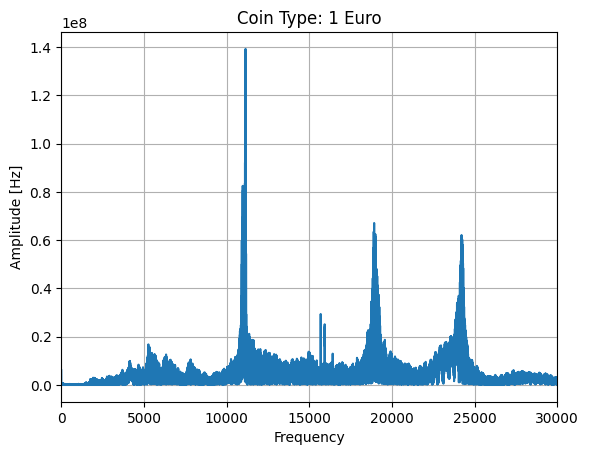

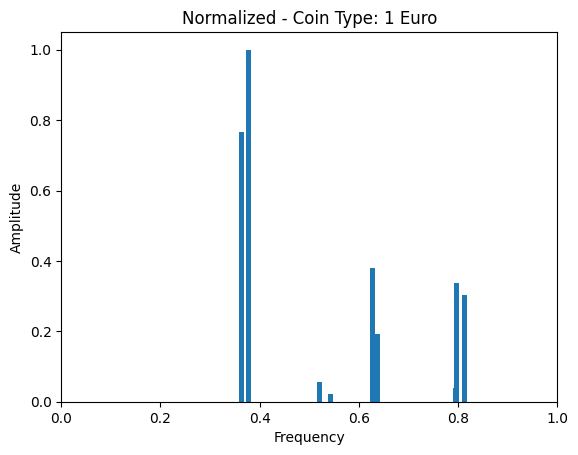

Shape of processed data for MLP: (1094, 20)
Shape of fft_magnitudes: (1094, 384513)
First 10 freq. in Hz: [0.         0.2652713  0.53054261 0.79581391 1.06108522 1.32635652
 1.59162783 1.85689913 2.12217044 2.38744174]



In [624]:
print(freqs.shape)
print(fft_magnitudes.shape)
plt.figure()
plt.plot(freqs, fft_magnitudes[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude [Hz]")
plt.title(f'Coin Type: {mapping[labels[0]]}')
plt.xlim(0, 30000)
plt.grid()
plt.show()

"""
print(freqs.shape)
print(fft_magnitudes.shape)
plt.figure()
plt.plot(freqs, fft_magnitudes[0])
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.xlim(11000,11500)
plt.grid()
plt.show()
"""

plt.figure()
plt.bar(normalized_frequencies[0], normalized_magnitudes[0], width=0.01)
plt.xlim(0,1)
plt.title(f'Normalized - Coin Type: {mapping[labels[0]]}')
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

print("Shape of processed data for MLP:", combined_features.shape)
print("Shape of fft_magnitudes:", fft_magnitudes.shape)
print("First 10 freq. in Hz:", freqs[:10])
print()

4. DEFINE MLP CLASSIFIER

In [617]:
class MLPClassifier(nn.Module):
    """Multi-Layer Perceptron (MLP) classifier for FFT-based features."""
    def __init__(self, input_size, dropout, num_classes):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout)
        
        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.relu4 = nn.ReLU()
        self.dropout4 = nn.Dropout(dropout)

        self.fc5 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

5. DATA PREPARATION (NORMALIZATION & SPLITTING)

In [618]:
def prepare_data(features, labels, test_size=0.2):
    """
    Prepares the dataset by splitting into training and test sets and normalizing.
    """
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=test_size, random_state=1234)
    scaler = MinMaxScaler(feature_range=(0,1))
    #X_train = scaler.fit_transform(X_train)
    #X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler

# Prepare data
X_train, X_test, y_train, y_test, scaler = prepare_data(combined_features, labels)

num_classes = len(set(labels))


6. TRAINING FUNCTION

In [619]:
def train_mlp(X_train, y_train, X_val, y_val, num_classes, epochs, batch_size, lr):
    """
    Trains the MLP model and records loss and accuracy.
    """
    # Convert data to PyTorch tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Define model
    input_size = X_train.shape[1]  # Now 200 instead of 100
    model = MLPClassifier(input_size, dropout, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    #scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)  # Min learning rate = 0.000001

    # Store losses and accuracies
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_train += y_batch.size(0)
            correct_train += (predicted == y_batch).sum().item()

        train_accuracy = correct_train / total_train
        train_losses.append(total_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Call `scheduler.step()` at the end of each epoch
        #scheduler.step()

        # Validation
        model.eval()
        total_val_loss, correct_val, total_val = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                total_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += y_batch.size(0)
                correct_val += (predicted == y_batch).sum().item()

        val_accuracy = correct_val / total_val
        val_losses.append(total_val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f} - "
              f"Train Acc: {train_accuracies[-1]:.4f} - Val Acc: {val_accuracies[-1]:.4f}")

    return model, train_losses, val_losses, train_accuracies, val_accuracies

7. MODEL EVALUATION

In [620]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluates the model on the test set and returns the accuracy.
    """
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)

    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

8. VISUALIZING TRAINING RESULTS

In [621]:
def plot_training_results(train_losses, val_losses, train_accuracies, val_accuracies):
    """
    Plots accuracy and loss curves for training and validation.
    """
    epochs = range(1, len(train_losses) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs")
    plt.legend()
    plt.grid()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label="Train Accuracy")
    plt.plot(epochs, val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epochs")
    plt.legend()
    plt.grid()

    plt.show()

9. TRAINING EXECUTION & FINAL MODEL TESTING

Epoch 1/500 - Train Loss: 3.8764 - Val Loss: 3.6020 - Train Acc: 0.1063 - Val Acc: 0.2968
Epoch 2/500 - Train Loss: 3.1119 - Val Loss: 2.9923 - Train Acc: 0.2720 - Val Acc: 0.4247
Epoch 3/500 - Train Loss: 2.5306 - Val Loss: 2.5914 - Train Acc: 0.3383 - Val Acc: 0.4475
Epoch 4/500 - Train Loss: 2.1661 - Val Loss: 2.2101 - Train Acc: 0.3737 - Val Acc: 0.4612
Epoch 5/500 - Train Loss: 1.9069 - Val Loss: 1.9786 - Train Acc: 0.4469 - Val Acc: 0.5251
Epoch 6/500 - Train Loss: 1.7531 - Val Loss: 1.7734 - Train Acc: 0.4686 - Val Acc: 0.5068
Epoch 7/500 - Train Loss: 1.6232 - Val Loss: 1.6659 - Train Acc: 0.4994 - Val Acc: 0.5434
Epoch 8/500 - Train Loss: 1.5493 - Val Loss: 1.5462 - Train Acc: 0.4914 - Val Acc: 0.5434
Epoch 9/500 - Train Loss: 1.4968 - Val Loss: 1.4764 - Train Acc: 0.5029 - Val Acc: 0.5525
Epoch 10/500 - Train Loss: 1.4859 - Val Loss: 1.4076 - Train Acc: 0.4983 - Val Acc: 0.5571
Epoch 11/500 - Train Loss: 1.4017 - Val Loss: 1.3480 - Train Acc: 0.5234 - Val Acc: 0.5890
Epoch 12

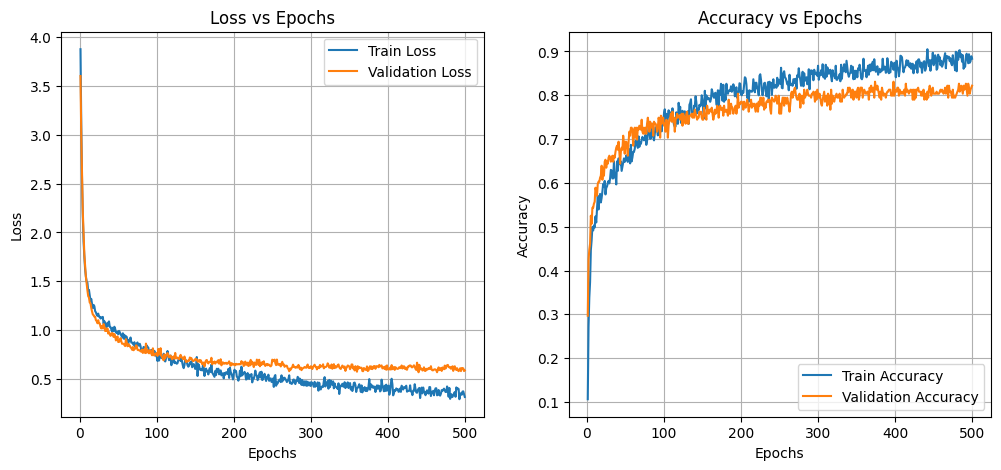

In [622]:
# Train the model with the new feature representation (Frequency + Amplitude)
model, train_losses, val_losses, train_accuracies, val_accuracies = train_mlp(X_train, y_train, X_test, y_test, num_classes, epochs=epochs, batch_size=batch_size, lr=learning_rate)

# Evaluate the model on the test set
test_accuracy = evaluate_model(model, X_test, y_test)

plot_training_results(train_losses, val_losses, train_accuracies, val_accuracies)

11. SAVING EXPERIMENT RESULTS

In [625]:
# Copy the script to save results
shutil.copyfile('./mlp fourier.ipynb', './' + results_dir + 'mlp_copy.ipynb')

'./Tests/Fourier/38/mlp_copy.ipynb'